In [1]:
import sys
from pathlib import Path

# notebooks/ is one level inside ROOT, so parent is ROOT
ROOT_DIR = Path.cwd().parent

sys.path.insert(0, str(ROOT_DIR ))  # or wherever kg_agents lives



In [2]:
import run_pipeline

run_pipeline.ROOT_DIR       = ROOT_DIR
run_pipeline.CORE_ONTOLOGY  = ROOT_DIR / "ontology_versions" / "core"      / "ontology_core_v0_0.json"
run_pipeline.EXTENSIONS     = ROOT_DIR / "ontology_versions" / "extensions" / "ontology_extensions_v0_0.json"
run_pipeline.CANDIDATES     = ROOT_DIR / "ontology_versions" / "candidates" / "ontology_candidates.json"
run_pipeline.ONTOLOGY_DIR   = ROOT_DIR / "ontology_versions" / "extensions"
run_pipeline.PROPOSALS_DIR  = ROOT_DIR / "ontology_versions" / "proposals"
run_pipeline.CHUNKS_DIR     = ROOT_DIR / "data" / "chunks"
run_pipeline.GRAPH_OUT      = ROOT_DIR / "data" / "graph_memory.json"
run_pipeline.LOG_DIR        = ROOT_DIR / "logs"

d:\Thesis\Mark_1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from run_pipeline import run_corpus, load_chunks

In [4]:
import json

def load_problem_chunks(problem_file: str, chunks_file: str):
    """Load problem chunk index and full chunk data."""
    problems = json.load(open(problem_file))
    all_chunks = json.load(open(chunks_file))
    
    # Build lookup: chunk_id → full chunk data
    chunk_lookup = {c["chunk_id"]: c for c in all_chunks}
    
    return problems, chunk_lookup


def get_chunks_by_issue(issue_type: str, problems: dict, chunk_lookup: dict):
    """
    Fetch all chunks that have a specific issue type.
    
    issue_type options:
        ALIGNMENT_DUPLICATE_MISSED
        RELATION_DOMAIN_RANGE_KNOWN_TYPES
        RELATION_RETRIES_EXHAUSTED
        ALL_RELATIONS_FILTERED
        ENTITY_EXCEPTION
        SEMANTICALLY_WRONG_EDGE
        PROPOSER_NO_CANDIDATES
    """
    results = []
    for entry in problems["chunks"]:
        if issue_type in entry["issues"]:
            chunk_id = entry["chunk_id"]
            chunk_data = chunk_lookup.get(chunk_id)
            results.append({
                "chunk_number": entry["chunk_number"],
                "chunk_id":     chunk_id,
                "issues":       entry["issues"],
                "details":      entry["details"],
                "chunk":        chunk_data,   # full chunk with heading + content
            })
    return results

In [5]:
from pathlib import Path

ROOT_DIR = Path.cwd().parent
CHUNKS_DIR     = ROOT_DIR / "data" / "chunks"

problems, chunk_lookup = load_problem_chunks(
    str(CHUNKS_DIR / "problem_chunks.json"),
    str(CHUNKS_DIR / "A First Course in Numerical Methods – Ascher & Greif_chunks.json")
)

# Get all alignment problem chunks
alignment_chunks = get_chunks_by_issue("ALIGNMENT_DUPLICATE_MISSED", problems, chunk_lookup)

print(f"Found {len(alignment_chunks)} chunks with alignment issues\n")

Found 130 chunks with alignment issues



In [6]:
alignment_chunks[0]["chunk"]

{'chunk_id': 'A First Course in Numerical Methods – Ascher & Greif_chunk_17',
 'doc_id': 'A First Course in Numerical Methods – Ascher & Greif',
 'heading': '2. Approximation errors',
 'content': 'Such errors arise when an approximate formula is used in place of the actual function to be evaluated.\n\nWe will often encounter two types of approximation errors:\n\n\\begin{itemize}\n  \\item Discretization errors arise from discretizations of continuous processes, such as interpolation, differentiation, and integration.\n  \\item Convergence errors arise in iterative methods. For instance, nonlinear problems must generally be solved approximately by an iterative process. Such a process would converge to the exact solution in infinitely many iterations, but we cut it off after a finite (hopefully small!) number of such iterations. Iterative methods in fact often arise in linear algebra.\n\\end{itemize}'}

In [7]:
chunks=[]
for i in range(2,10):
    chunks.append(alignment_chunks[i]["chunk"])

In [8]:
chunks

[{'chunk_id': 'A First Course in Numerical Methods – Ascher & Greif_chunk_20',
  'doc_id': 'A First Course in Numerical Methods – Ascher & Greif',
  'heading': 'Discretization errors in action',
  'content': "Let us show an example that illustrates the behavior of discretization errors.\n\nExample 1.2. Consider the problem of approximating the derivative \\(f^{\\prime}\\left(x_{0}\\right)\\) of a given smooth function \\(f(x)\\) at the point \\(x=x_{0}\\). For instance, let \\(f(x)=\\sin (x)\\) be defined on the real line \\(-\\infty<x<\\infty\\), and set \\(x_{0}=1.2\\). Thus, \\(f\\left(x_{0}\\right)=\\sin (1.2) \\approx 0.932 \\ldots\\).\n\nFurther, consider a situation where \\(f(x)\\) may be evaluated at any point \\(x\\) near \\(x_{0}\\), but \\(f^{\\prime}\\left(x_{0}\\right)\\) may not be directly available or is computationally expensive to evaluate. Thus, we seek ways to approximate \\(f^{\\prime}\\left(x_{0}\\right)\\) by evaluating \\(f\\) at \\(x\\) near \\(x_{0}\\).\n\nA 

[Logger] Run 'problem_alignment_first5' → d:\Thesis\Mark_1\logs\problem_alignment_first5_20260502_012908.jsonl
[EntityIndex] No existing index at d:\Thesis\Mark_1\notebooks\data\entity_index — starting fresh.


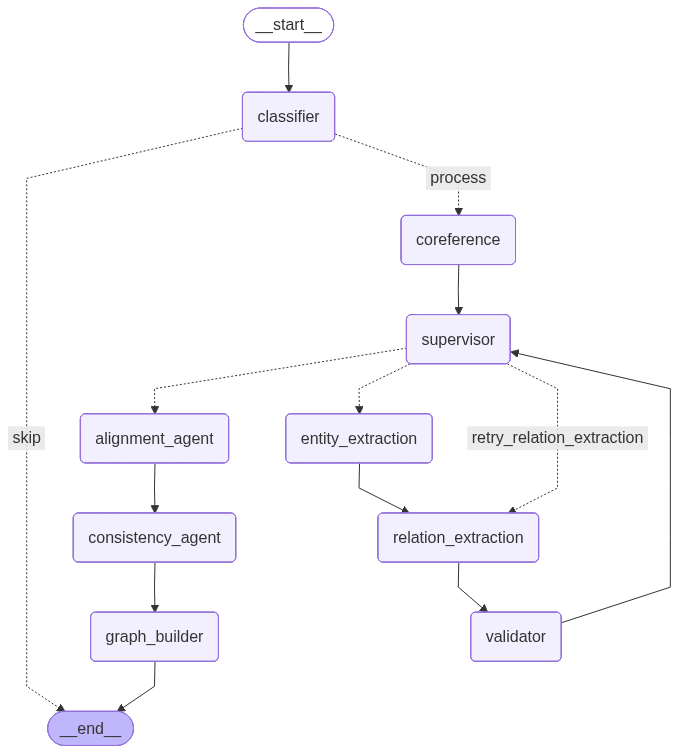

None
[Pipeline] No existing document memory found at d:\Thesis\Mark_1\notebooks\data\document_memory.json — starting fresh.

KG CONSTRUCTION PIPELINE — problem_alignment_first5
Documents : 1
Log       : d:\Thesis\Mark_1\logs\problem_alignment_first5_20260502_012908.jsonl


INGESTING: tmpa4tg7etr  (8 chunks)

[1/8] Chunk: A First Course in Numerical Methods – Ascher & Greif_chunk_20

----- CHUNK CLASSIFIER -----
  Type: content | heading contains content keyword 'discretization'

----- COREFERENCE -----
  [coref] LLM detected 6 candidate reference(s)
  [coref] dropped 'this fundamental theorem' → 'None' (failed validation)
  [coref] dropped 'the obtained approximation' → 'None' (failed validation)
  [coref] dropped 'the discretization error' → 'None' (failed validation)
  [coref] dropped 'the slope of the tangent' → 'None' (failed validation)
  [coref] dropped 'the chord' → 'None' (failed validation)
  [coref] dropped 'the error' → 'None' (failed validation)
  [coref] 0 resolution(s) pa

In [9]:
# Write to a temp file and run
import tempfile

with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
    json.dump(chunks, f)
    temp_path = f.name

graph, ontology = run_corpus(
        chunks_files   = [temp_path],
        run_name       = "problem_alignment_first5",
        run_cli_review = True,    # set False to skip interactive review
    )